**SECTION 1: INTRODUCTION & DATASET OVERVIEW**

**1.1 Project **

Dataset project analysis : **Analysis of Energy Performance Certificates (DPE) in the Var region**

Student : Octave GOUDON

Date : January 25, 2026

Dataset : diagnostics de performance énergétique DPE

**1.2 Dataset Source & Context**

Link to dataset : https://www.data.gouv.fr/dataservices/api-dpe-logements

Description of what the data represents : National database of energy performance certificates for housing in France. Data published by ADEME. Contains information on :
- Housing area,
- Year of construction,
- Type of heating system,
- Energy efficiency rating (A–G),
- CO₂ emissions,
- Energy consumption (kWh/m²/year)

Source : The dataset used in this project comes from the French national database of Diagnostics de Performance Énergétique (DPE), published by the ADEME on the open data platform data.gouv.fr.

Citation : ADEME. Base de données nationale des Diagnostics de Performance Énergétique (DPE). Data.gouv.fr.

Number of observations and variables : Contains 226,532 observations of residential energy performance diagnostics with 131 variables describing building characteristics, energy consumption estimates, heating systems, and environmental performance indicators.

**1.3 Research Questions**

Possible research questions:

• Do older homes consume more energy?

• Does the type of heating influence energy consumption?

• Is the size of the home related to total energy consumption?

• Can the energy rating of a home be predicted?

**SECTION 2: DATA LOADING & EXPLORATION**

**2.1 Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv('/content/drive/My Drive/Dossier_projet_stats/dep_83.csv')

print(f"Shape: {df.shape}")
print(df.head(10))
print(df.info())
print(df.describe())

/tmp/ipykernel_4697/1635590899.py:8: DtypeWarning: Columns (27,35,36,37,43,76,92,93,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/Dossier_projet_stats/dep_83.csv')


Shape: (226532, 131)
    id     numero_dpe  usr_diagnostiqueur_id  usr_logiciel_id  \
0   78  1383V1000001B                   4020                2   
1   90  1383V2000001C                   8586                3   
2  111  1383V1000002C                   4020                2   
3  112  1383V1000003D                   8273                3   
4  153  1383V1000004E                   8273                3   
5  172  1383V2000002D                   8586                3   
6  221  1383L1000001A                   8273                3   
7  236  1383L1000002B                   4020                2   
8  315  1383V1000005F                   8273                3   
9  360  1383V2000003E                   8586                3   

   tr001_modele_dpe_id  nom_methode_dpe   version_methode_dpe  \
0                    1        3CL - DPE                 V2012   
1                    2          Facture               facture   
2                    1        3CL - DPE                 V2012   
3  

**2.2 Initial Data Assessment**

 Variable types (numerical, categorical)

In [ ]:
#Information about column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226532 entries, 0 to 226531
Columns: 131 entries, id to tv018_zone_ete_rclim_dernier_etage
dtypes: float64(48), int64(29), object(54)
memory usage: 226.4+ MB


In [ ]:
#Numerical variables
df.select_dtypes(include=['int64','float64']).columns

Index(['id', 'usr_diagnostiqueur_id', 'usr_logiciel_id', 'tr001_modele_dpe_id',
       'consommation_energie', 'estimation_ges', 'tr002_type_batiment_id',
       'tr012_categorie_erp_id', 'tr013_type_erp_id', 'annee_construction',
       'surface_habitable', 'surface_thermique_lot', 'tv016_departement_id',
       'nom_centre_commercial', 'surface_commerciale_contractuelle',
       'portee_dpe_batiment', 'shon', 'surface_utile',
       'surface_thermique_parties_communes', 'en_souterrain', 'en_surface',
       'nombre_niveaux', 'nombre_circulations_verticales', 'nombre_boutiques',
       'presence_verriere', 'surface_verriere', 'type_vitrage_verriere',
       'nombre_entrees_avec_sas', 'nombre_entrees_sans_sas',
       'surface_baies_orientees_nord', 'surface_baies_orientees_est_ouest',
       'surface_baies_orientees_sud', 'surface_planchers_hauts_deperditifs',
       'surface_planchers_bas_deperditifs',
       'surface_parois_verticales_opaques_deperditives', 'etat_avancement',
      

In [ ]:
#Categorical variables
df.select_dtypes(include=['object']).columns

Index(['numero_dpe', 'nom_methode_dpe', 'version_methode_dpe',
       'nom_methode_etude_thermique', 'version_methode_etude_thermique',
       'date_visite_diagnostiqueur', 'date_etablissement_dpe',
       'date_arrete_tarifs_energies',
       'commentaires_ameliorations_recommandations',
       'explication_personnalisee', 'classe_consommation_energie',
       'classe_estimation_ges', 'secteur_activite', 'commune',
       'arrondissement', 'type_voie', 'nom_rue', 'numero_rue', 'batiment',
       'escalier', 'etage', 'porte', 'code_postal', 'code_insee_commune',
       'code_insee_commune_actualise', 'numero_lot', 'quote_part',
       'partie_batiment', 'organisme_certificateur',
       'adresse_organisme_certificateur', 'date_reception_dpe', 'geo_type',
       'geo_adresse', 'geo_id', 'geo_l4', 'geo_l5', 'tr001_modele_dpe_code',
       'tr001_modele_dpe_modele', 'tr001_modele_dpe_description',
       'tr001_modele_dpe_fichier_vierge', 'tr001_modele_dpe_type',
       'tr001_modele_dpe_

Data quality (missing values, duplicates)

In [ ]:
#Missing values
df.isnull().sum()

,0
id,0
numero_dpe,0
usr_diagnostiqueur_id,0
usr_logiciel_id,0
tr001_modele_dpe_id,0
...,...
tv018_zone_ete_code,0
tv018_zone_ete_sclim_inf_150,0
tv018_zone_ete_sclim_sup_150,0
tv018_zone_ete_rclim_autres_etages,0


In [ ]:
#Missing values
#To see the percentage.
#This allows us to identify variables with many missing values.
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

,0
type_vitrage_verriere,100.000000
nom_centre_commercial,100.000000
geo_l5,99.998234
partie_batiment,99.972189
tr012_categorie_erp_code,99.807091
...,...
tv018_zone_ete_code,0.000000
tv018_zone_ete_sclim_inf_150,0.000000
tv018_zone_ete_sclim_sup_150,0.000000
tv018_zone_ete_rclim_autres_etages,0.000000


In [ ]:
#Duplicates
#This gives the number of identical lines.
df.duplicated().sum()

np.int64(0)

Basic statistics for each variable

In [ ]:
#For numerical variables:
df.describe()
#This displays: mean, standard deviation, minimum, maximum, quartiles

,id,usr_diagnostiqueur_id,usr_logiciel_id,tr001_modele_dpe_id,consommation_energie,estimation_ges,tr002_type_batiment_id,tr012_categorie_erp_id,tr013_type_erp_id,annee_construction,...,tv016_departement_fecs_ancienne_i_c,tv016_departement_fecs_recente_i_c,tv017_zone_hiver_t_ext_moyen,tv017_zone_hiver_peta_cw,tv017_zone_hiver_dh14,tv017_zone_hiver_prs1,tv018_zone_ete_sclim_inf_150,tv018_zone_ete_sclim_sup_150,tv018_zone_ete_rclim_autres_etages,tv018_zone_ete_rclim_dernier_etage
count,2.265320e+05,226532.000000,226532.000000,226532.000000,226532.000000,226532.000000,226532.000000,437.000000,9227.000000,226532.000000,...,226532.0,226532.0,2.265320e+05,226532.0,226532.0,2.265320e+05,226532.0,226532.0,226532.0,226532.0
mean,5.902638e+06,11310.740553,5.381231,4.213343,150.935636,12.260191,1.669287,1.663616,22.703479,1907.471695,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0
std,3.352701e+06,5466.820180,3.810398,4.451695,949.567109,35.357856,0.562512,1.421938,2.396316,383.362804,...,0.0,0.0,4.057741e-11,0.0,0.0,1.235281e-11,0.0,0.0,0.0,0.0
min,7.800000e+01,67.000000,2.000000,1.000000,-236.000000,-12.000000,1.000000,1.000000,1.000000,-1.000000,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0
25%,3.110219e+06,8122.000000,3.000000,1.000000,59.060000,3.080000,1.000000,1.000000,23.000000,1948.000000,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0
50%,5.868252e+06,11056.000000,3.000000,1.000000,147.635000,7.730000,2.000000,1.000000,23.000000,1978.000000,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0
75%,8.798793e+06,15034.000000,10.000000,9.000000,211.000000,14.000000,2.000000,1.000000,23.000000,2001.000000,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0
max,1.170851e+07,25258.000000,16.000000,23.000000,439925.000000,14319.000000,3.000000,5.000000,30.000000,32767.000000,...,42.0,62.0,9.650000e+00,14.5,22200.0,2.900000e+00,5.0,7.0,4.0,5.0


Range of values

In [ ]:
#'range of values' means: max - min
#The range is given by:
df.max(numeric_only=True) - df.min(numeric_only=True)

,0
id,11708431.0
usr_diagnostiqueur_id,25191.0
usr_logiciel_id,14.0
tr001_modele_dpe_id,22.0
consommation_energie,440161.0
...,...
tv017_zone_hiver_prs1,0.0
tv018_zone_ete_sclim_inf_150,0.0
tv018_zone_ete_sclim_sup_150,0.0
tv018_zone_ete_rclim_autres_etages,0.0


**SECTION 3: DATA CLEANING & PREPARATION**

**3.1 Handle Missing Values**

In [ ]:
# Check missing data
print(df.isnull().sum())

id                                    0
numero_dpe                            0
usr_diagnostiqueur_id                 0
usr_logiciel_id                       0
tr001_modele_dpe_id                   0
                                     ..
tv018_zone_ete_code                   0
tv018_zone_ete_sclim_inf_150          0
tv018_zone_ete_sclim_sup_150          0
tv018_zone_ete_rclim_autres_etages    0
tv018_zone_ete_rclim_dernier_etage    0
Length: 131, dtype: int64


In [ ]:
#To see the percentage of missing values:
missing_percent = (df.isnull().sum()/len(df)*100).round(2)
missing_percent.sort_values(ascending=False)
#This will allow you to identify:
#- variables with no missing data
#- those with few missing data points
#- those with many missing data points

,0
geo_l5,100.00
nom_centre_commercial,100.00
type_vitrage_verriere,100.00
partie_batiment,99.97
tr012_categorie_erp_code,99.81
...,...
tv018_zone_ete_code,0.00
tv018_zone_ete_sclim_inf_150,0.00
tv018_zone_ete_sclim_sup_150,0.00
tv018_zone_ete_rclim_autres_etages,0.00


**Strategy** (delete row, impute, keep as is):

Missing values were identified by calculating the number and percentage of null values for each variable. Some variables contained a very high proportion of missing data and were therefore removed from the dataset to avoid introducing bias in the analysis.

For variables with a small proportion of missing values, the affected rows were removed.

Columns with more than 50% missing values were removed from the dataset in order to improve data quality and avoid unreliable analysis. This threshold ensures that only variables with sufficient information are retained for the study.

For important numerical variables, missing values were imputed using the median, as it is less sensitive to outliers than the mean.

Categorical variables with missing values were filled with a placeholder category (“Unknown”) to preserve the observations while indicating missing information.

Therefore:
- For cases where few values are missing (<5%), we delete the lines.
- For cases where lots of values are missing (>50%), we delete the column.
- For important numerical variables, missing values were imputed using the median.
- For categorical variables, missing values are replaced by “Unknown”.

In [ ]:
#For cases where few values are missing (<5%), we delete the lines:
df = df.dropna(subset=['annee_construction'])
df = df.dropna(subset=['surface_habitable'])

#For cases where lots of values are missing (>50%), we delete the column.
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

#For important numerical variables, missing values were imputed using the median.
if 'consommation_energie' in df.columns:
    df['consommation_energie'] = df['consommation_energie'].fillna(df['consommation_energie'].median())
if 'estimation_ges' in df.columns:
    df['estimation_ges'] = df['estimation_ges'].fillna(df['estimation_ges'].median())

#For categorical variables, missing values are replaced by “Unknown”.
categorical_cols_to_fill = ['secteur_activite', 'classe_consommation_energie', 'classe_estimation_ges', 'commune']
for col in categorical_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [ ]:
#In classe_estimation_ges and classe_consommation_energie, there are some 'N' that mean 'non déterminé / non applicable'.
#Those columns are important later, thus when there are 'N', we prefer to delete the line.
df = df[(df["classe_estimation_ges"] != "N") & (df["classe_consommation_energie"] != "N")]

**3.2 Handle Duplicates**

In [ ]:
# Check for exact duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


Duplicate rows are also checked to ensure data integrity.

If there are some duplicates, we should remove them by executing:

df = df.drop_duplicates()

But here, there is not any duplicates.

Nevertheless, there is an issue with the column commune: there are some 'other kinds of duplicates': for example, there are Hyères and Hyeres.

Further Cleaning of 'commune' Column

To ensure even more consistent commune names, we will perform two additional cleaning steps:
1.  Replace hyphens (`-`) with spaces.
2.  Replace accented characters with their unaccented equivalents.

In [ ]:
import unicodedata

def remove_accents_and_hyphens(text):
    if isinstance(text, str):
        # Replace hyphens with spaces first
        text = text.replace('-', ' ')
        # Normalize to NFD (Normalization Form Canonical Decomposition) and remove diacritics
        text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
        return text
    return text

# Apply the cleaning function to the 'commune' column
df['commune'] = df['commune'].apply(remove_accents_and_hyphens)

**3.3 Data Type Conversions**

We have to check if types are correct.
We ensure that:

• Numeric variables are in int or float format

• Categorical variables are in category format

• Dates are in datetime format

This allows us to improve statistical analysis and create graphs later.


In [ ]:
#This shows the type of each variable.
df.dtypes

,0
id,int64
numero_dpe,object
usr_diagnostiqueur_id,int64
usr_logiciel_id,int64
tr001_modele_dpe_id,int64
...,...
tv018_zone_ete_code,object
tv018_zone_ete_sclim_inf_150,int64
tv018_zone_ete_sclim_sup_150,int64
tv018_zone_ete_rclim_autres_etages,float64


Here, there are no data type problems, but if there were, we would need to convert it to the correct type by executing for example:

df['column_name'] = pd.to_datetime(df['column_name'])

or

df['category'] = df['category'].astype('category')

**3.4 Outlier Detection & Investigation**

Outliers are data points that are "abnormally" far from others.

They are detected by checking extreme values by executing:

*df['nom_de_ta_colonne'].describe()*

Or by using the IQR Method:

*def find_outliers_iqr(data, column):*

*Q1 = data[column].quantile(0.25)*

*Q3 = data[column].quantile(0.75)*

*IQR = Q3 - Q1*

*lower = Q1 - 1.5 * IQR*

*upper = Q3 + 1.5 * IQR*

*return data[(data[column] < lower) | (data[column] > upper)]*

- for consommation_energie:

Maybe due to errors, there are null values and negative values. In addition to this, there are a minority of values that are extremely high because they concern groups of dwellings and not dwellings.

To ensure data quality, observations with consommation_energie ≤ 0 and those exceeding 600 kWh/m²/year were removed from the dataset.

This filtering step helps avoid distortions in the statistical analysis caused by erroneous or extreme values.

In [ ]:
df = df[(df["consommation_energie"] > 0) & (df["consommation_energie"] <= 600)]

- for estimation_ges:

Maybe due to errors, there are null values and negative values. In addition to this, there are a minority of values that are extremely high because they concern groups of dwellings and not dwellings.

To ensure data quality, observations with estimation_ges ≤ 0 and those exceeding 100 kgCO₂e/m²/year were removed from the dataset.


In [ ]:
df = df[(df["estimation_ges"] > 0) & (df["estimation_ges"] <= 100)]

- for annee_construction (int64):

To indicate that the date is unknown, it is often written as 1. Furthermore, there are sometimes impossible dates such as 6060.

To ensure data quality, observations with annee_construction ≤ 1900 and those exceeding 2027 were removed from the dataset.


In [ ]:
df = df[(df["annee_construction"] > 1900) & (df["annee_construction"] <= 2027)]

- for surface_habitable:

Maybe due to errors, there are null values. In addition to this, there are a minority of values that are extremely high because they concern groups of dwellings and not dwellings.

To ensure data quality, observations with surface_habitable ≤ 10 and those exceeding 500 m² were removed from the dataset.


In [ ]:
df = df[(df["surface_habitable"] > 10) & (df["surface_habitable"] <= 500)]

**3.5 Data Cleaning Summary**

| Unnamed: 0            | Observed issue                                                                     | What is done to fix it                                                                       | Explainations |
|----------------------|-------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------|--------------|
| Handle missing values | Some observations have a few missing values (<5%)                                  | The line is deleted                                                                          | There are enough observations that we can remove those that are rather incomplete without compromising the integrity of the statistics. |
|                      | Some variables have a lot of missing values (>50%)                                 | The column is deleted                                                                        | Columns with more than 50% missing values were removed from the dataset in order to improve data quality and avoid unreliable analysis. This threshold ensures that only variables with sufficient information are retained for the study. |
|                      | Some important variables have a few missing values                                 | Missing values were imputed using the median                                                 | For important numerical variables, missing values were imputed using the median, as it is less sensitive to outliers than the mean. |
|                      | Some categorical variables have a few missing values                               | Missing values are replaced by “Unknown”                                                     | Categorical variables with missing values were filled with a placeholder category (“Unknown”) to preserve the observations while indicating missing information. |
| Handle duplicates     | Some 'commune' are written with different spellings                                                  | Dashes and accents have been removed.                                                                                              | |
| Data type conversions | Here, there are no data type problems                                              |                                                                                               | |
| Outliers              | Some values of consommation_energie are abnormally far from others or inconsistent | Observations with consommation_energie ≤ 0 and those exceeding 600 kWh/m²/year were removed | Maybe due to errors, there were null values and negative values. |
|                      | Some values of estimation_ges are abnormally far from others or inconsistent       | Observations with estimation_ges ≤ 0 and those exceeding 100 kgCO₂e/m²/year were removed     | Maybe due to errors, there were null values and negative values. |
|                      | Some values of annee_construction are inconsistent                                 | Observations with annee_construction ≤ 1900 and those exceeding 2027 were removed            | To indicate that the date was unknown, it was often written as 1. |
|                      | Some values of surface_habitable are abnormally far from others or inconsistent    | Observations with surface_habitable ≤ 10 and those exceeding 500 m² were removed            | Maybe due to errors, there were null values. |

**SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)**

**4.1 Univariate Analysis**

For Numerical Variables:

       consommation_energie  estimation_ges  annee_construction  \
count         189412.000000   189412.000000       189412.000000   
mean             168.827222       13.679395         1984.485508   
std               88.401304       14.174580           22.972758   
min                0.110000        0.010000         1901.000000   
25%              109.460000        5.000000         1974.000000   
50%              163.000000        8.790000         1983.000000   
75%              220.692500       16.000000         2005.000000   
max              600.000000      100.000000         2021.000000   

       surface_habitable  
count      189412.000000  
mean           81.576192  
std            52.481997  
min            10.030000  
25%            46.920000  
50%            69.490000  
75%            99.320000  
max           500.000000  


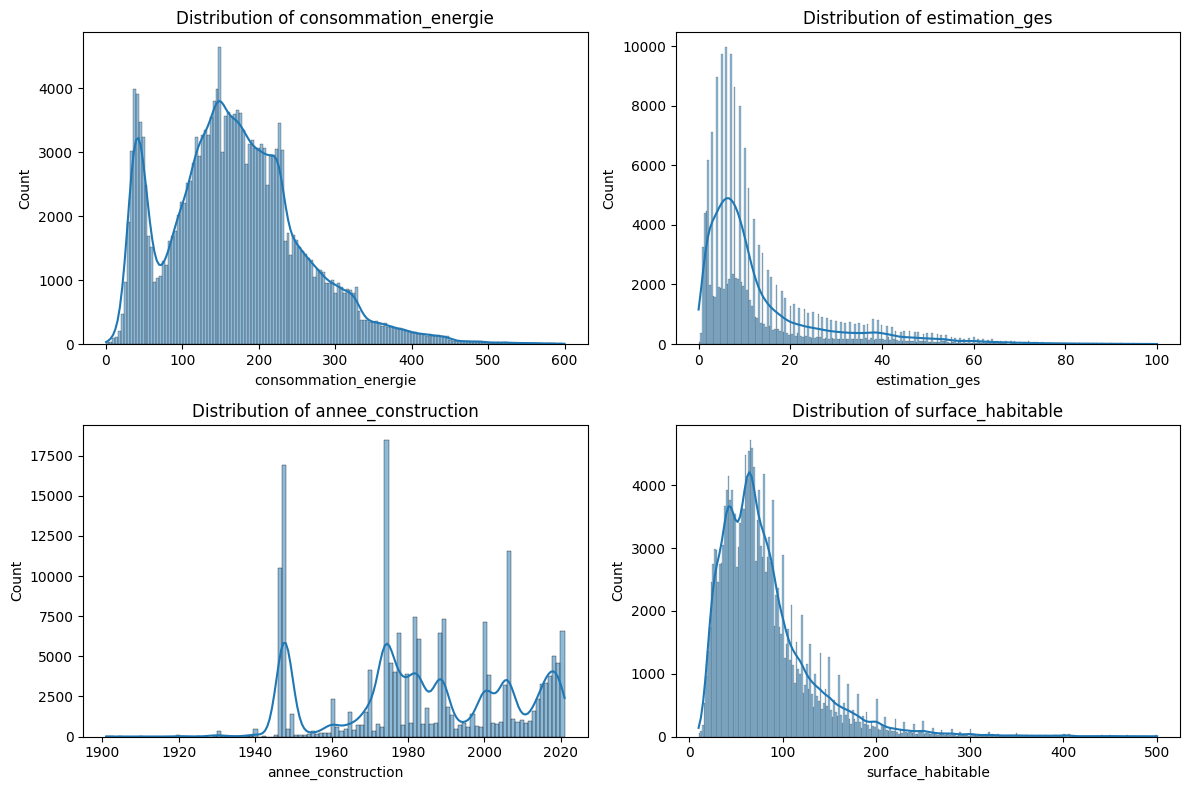

In [ ]:
# Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['consommation_energie', 'estimation_ges', 'annee_construction', 'surface_habitable']):
    ax = axes.flat[i]
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()

# Summary statistics
print(df[['consommation_energie', 'estimation_ges', 'annee_construction', 'surface_habitable']].describe())

For Categorical Variables:


classe_consommation_energie:
classe_consommation_energie
D    67226
C    46969
E    30285
A    21823
B    15006
F     7143
G      960
Name: count, dtype: int64
Unique values: 7

classe_estimation_ges:
classe_estimation_ges
B    59414
A    56671
C    36854
D    18795
E    13327
F     3805
G      546
Name: count, dtype: int64
Unique values: 7

commune:
commune
TOULON                                        20357
HYERES                                        10540
FREJUS                                        10536
LA SEYNE SUR MER                              10146
SAINT RAPHAEL                                  7697
                                              ...  
CADIERE D'AZUR                                    1
ST CYR/MER                                        1
Les Mayons                                        1
e du Merou   Saint Clair 83980 LE LAVANDOU        1
DUNES                                             1
Name: count, Length: 1135, dtype: int64
Unique values: 1135

nom_m

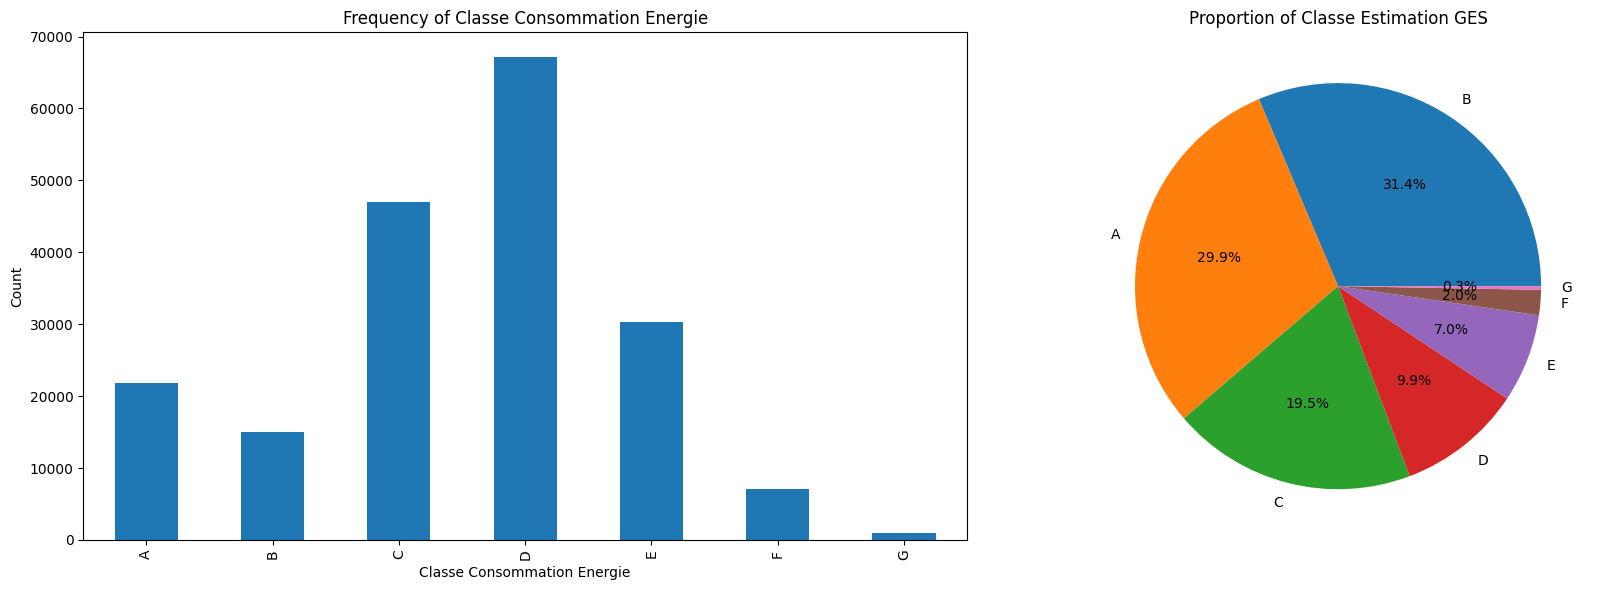

In [ ]:
# Frequencies
# Use categorical_cols_to_fill which was defined earlier, and add other relevant categorical columns
categorical_columns = ['classe_consommation_energie', 'classe_estimation_ges', 'commune', 'nom_methode_dpe']

for col in categorical_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")
    else:
        print(f"\nColumn '{col}' not found in DataFrame.")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for 'classe_consommation_energie'
if 'classe_consommation_energie' in df.columns:
    counts = df['classe_consommation_energie'].value_counts()
    # alphabetically
    sorted_index = counts.index.sort_values()
    sorted_counts = counts.reindex(sorted_index)
    sorted_counts.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Frequency of Classe Consommation Energie')
    axes[0].set_xlabel('Classe Consommation Energie')
    axes[0].set_ylabel('Count')
else:
    axes[0].set_title("Column 'classe_consommation_energie' not found")

# Plot for 'classe_estimation_ges'
if 'classe_estimation_ges' in df.columns:
    df['classe_estimation_ges'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Proportion of Classe Estimation GES')
    axes[1].set_ylabel('')
else:
    axes[1].set_title("Column 'classe_estimation_ges' not found")

plt.tight_layout()
plt.show()

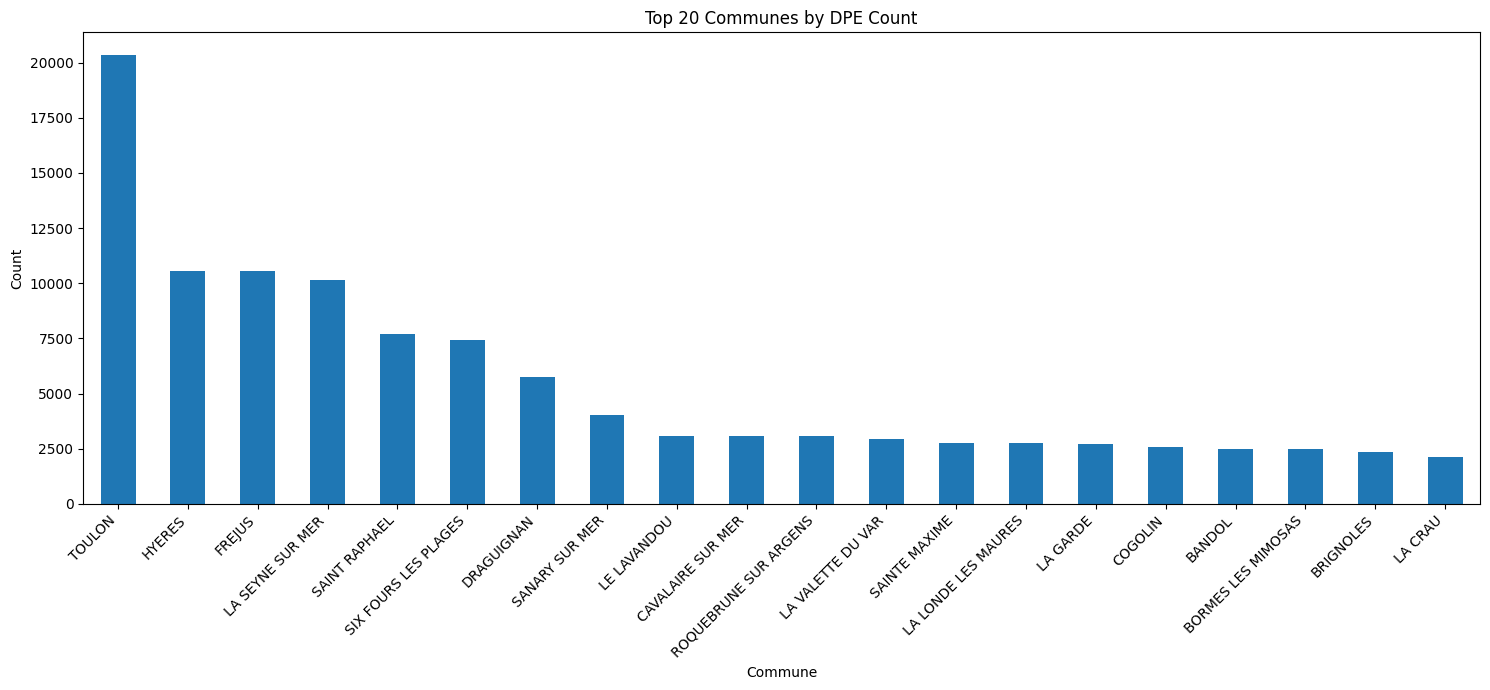

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for 'commune'
plt.figure(figsize=(15, 7))
df['commune'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Communes by DPE Count')
plt.xlabel('Commune')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**4.2 Bivariate Analysis**

Numerical-Numerical:

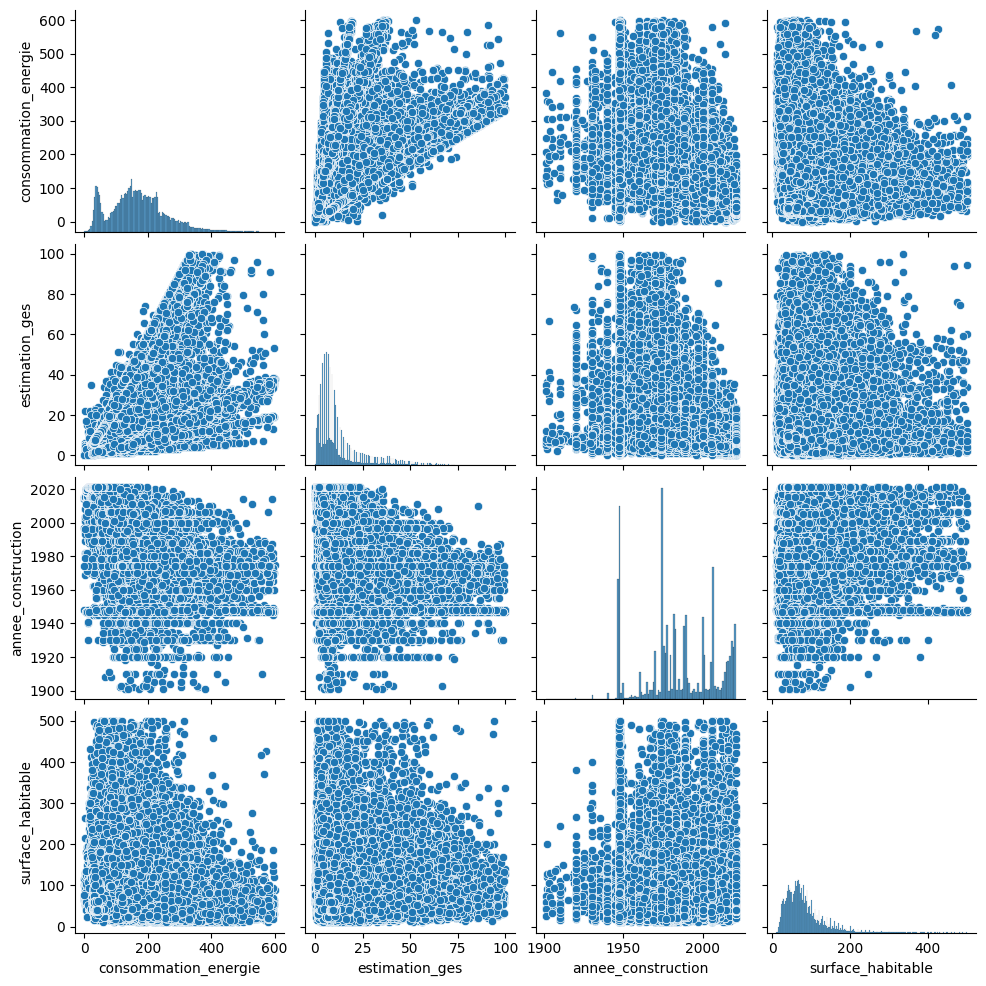

In [ ]:
# Scatterplot matrix
sns.pairplot(df[['consommation_energie', 'estimation_ges', 'annee_construction', 'surface_habitable']])

<Axes: >

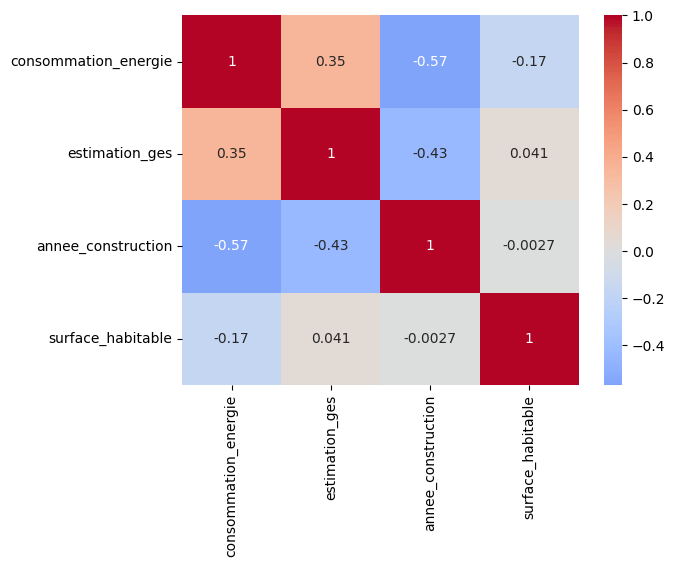

In [ ]:
# Correlation heatmap
corr_matrix = df[['consommation_energie', 'estimation_ges', 'annee_construction', 'surface_habitable']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

Numerical-Categorical:

<Axes: xlabel='classe_consommation_energie', ylabel='consommation_energie'>

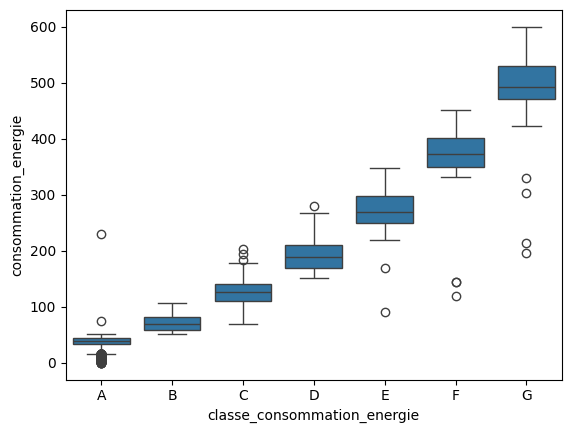

In [ ]:
# Boxplots
sns.boxplot(data=df, x='classe_consommation_energie', y='consommation_energie', order=sorted(df['classe_consommation_energie'].unique()))

<Axes: xlabel='classe_consommation_energie', ylabel='consommation_energie'>

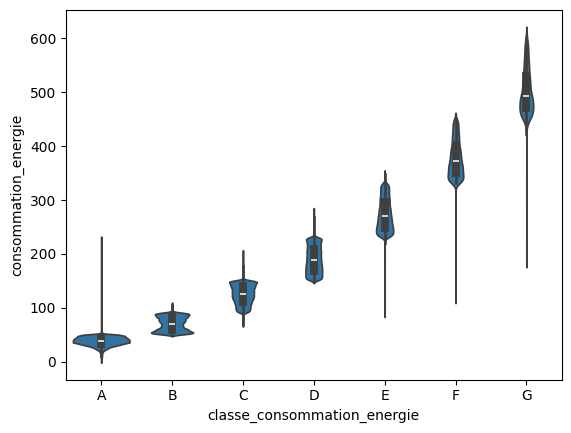

In [ ]:
# Violinplots
sns.violinplot(data=df, x='classe_consommation_energie', y='consommation_energie', order=sorted(df['classe_consommation_energie'].unique()))

In [ ]:
# Summary by group
df.groupby('classe_consommation_energie')['consommation_energie'].describe()

,count,mean,std,min,25%,50%,75%,max
classe_consommation_energie,,,,,,,,
A,21823.0,38.182734,8.183504,0.11,33.2900,38.88,44.420,230.00
B,15006.0,70.224026,12.764092,50.95,58.0000,70.01,82.100,106.00
C,46969.0,124.755287,17.005865,69.00,111.0000,126.00,140.000,203.00
D,67226.0,189.800977,23.487738,150.81,169.0425,188.92,210.000,280.00
E,30285.0,273.740713,28.471161,90.00,249.0000,270.00,297.000,348.00
F,7143.0,377.862360,33.120664,120.00,350.1550,372.00,402.005,450.82
G,960.0,502.456635,42.817140,197.00,470.8375,493.00,530.000,600.00


<Axes: xlabel='classe_estimation_ges', ylabel='estimation_ges'>

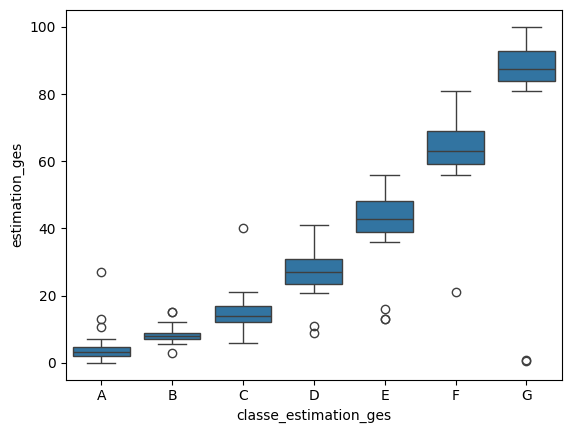

In [ ]:
# Boxplots
sns.boxplot(data=df, x='classe_estimation_ges', y='estimation_ges', order=sorted(df['classe_estimation_ges'].unique()))

<Axes: xlabel='classe_estimation_ges', ylabel='estimation_ges'>

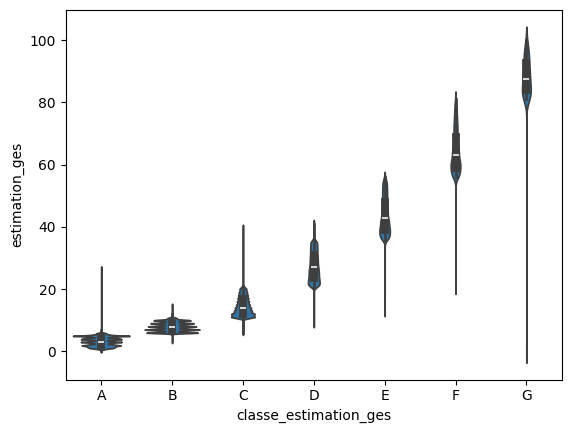

In [ ]:
# Violinplots
sns.violinplot(data=df, x='classe_estimation_ges', y='estimation_ges', order=sorted(df['classe_estimation_ges'].unique()))

In [ ]:
# Summary by group
df.groupby('classe_estimation_ges')['estimation_ges'].describe()

,count,mean,std,min,25%,50%,75%,max
classe_estimation_ges,,,,,,,,
A,56671.0,3.298219,1.452853,0.01,2.0000,3.18,4.700,27.00
B,59414.0,8.033485,1.420597,3.00,7.0000,8.00,9.000,15.00
C,36854.0,14.502025,2.805707,6.00,12.0000,14.00,16.850,40.00
D,18795.0,27.353447,4.360363,9.00,23.5000,27.00,31.000,41.00
E,13327.0,43.848493,5.593745,13.00,39.0000,42.92,48.025,55.99
F,3805.0,64.598852,6.539886,21.00,59.0500,63.00,69.000,80.97
G,546.0,88.083407,7.543248,0.63,83.9625,87.56,92.720,100.00


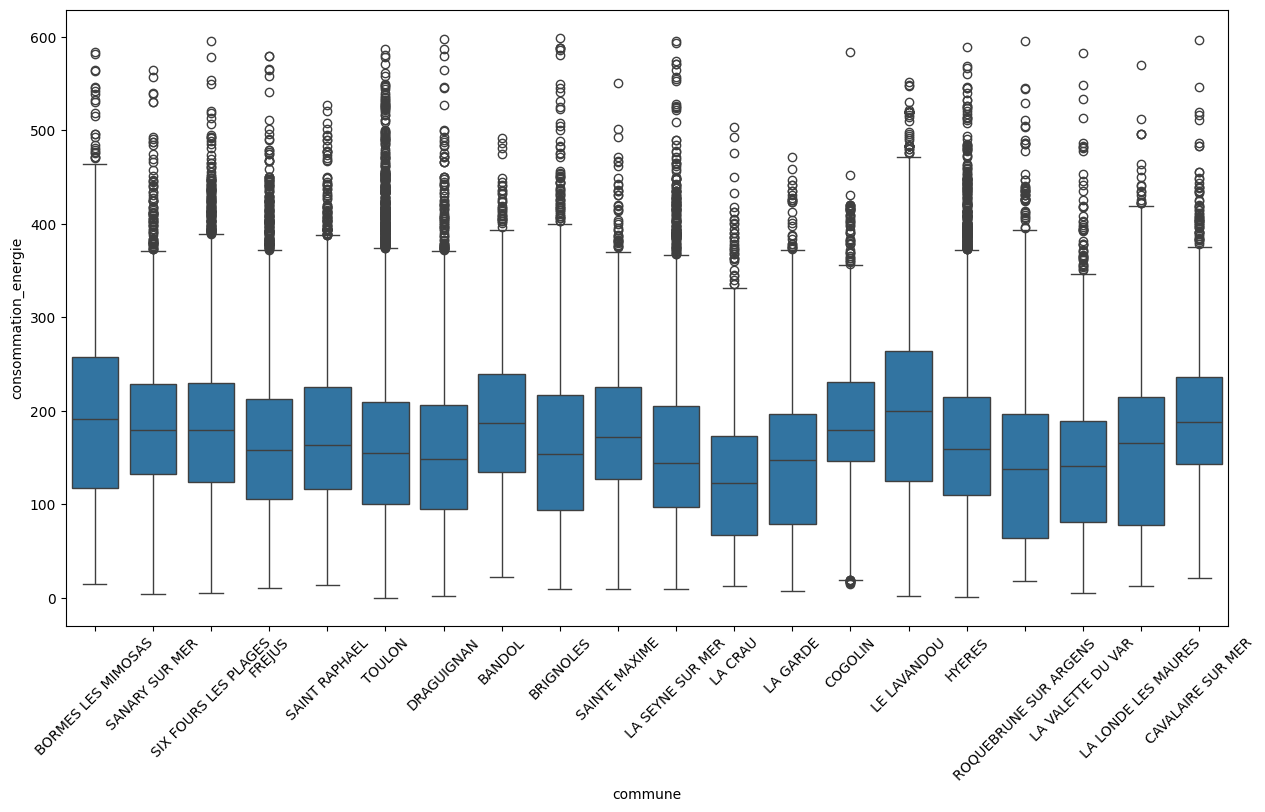

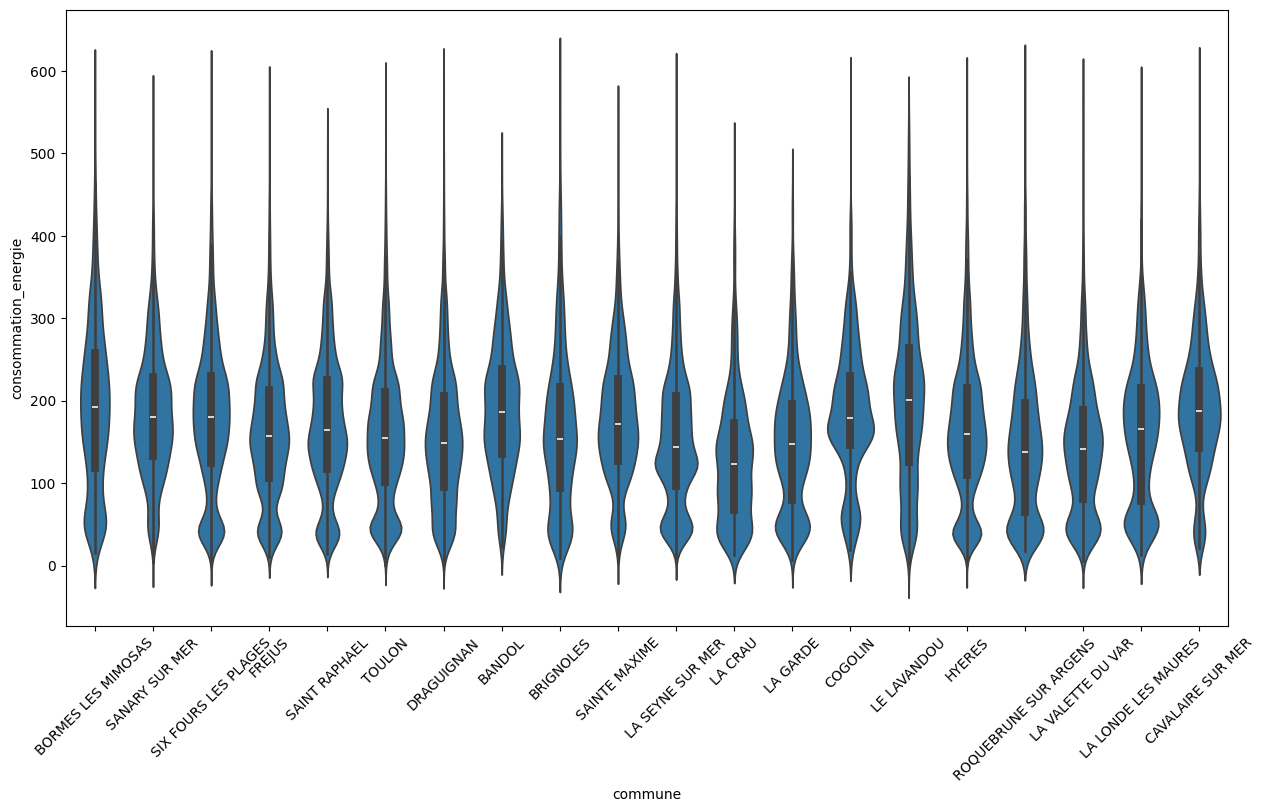

In [ ]:
# Boxplots et Violinplots
top_20_communes = df['commune'].value_counts().nlargest(20).index

df_top20 = df[df['commune'].isin(top_20_communes)]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.boxplot(data=df_top20, x='commune', y='consommation_energie')

plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 8))
sns.violinplot(data=df_top20, x='commune', y='consommation_energie')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Summary by group
df.groupby('commune')['consommation_energie'].describe()

,count,mean,std,min,25%,50%,75%,max
commune,,,,,,,,
,2.0,210.025,0.516188,209.66,209.8425,210.025,210.2075,210.39
TOURTOUR,1.0,279.000,NaN,279.00,279.0000,279.000,279.0000,279.00
. BRIGNOLES,5.0,195.290,39.336429,142.04,174.4500,194.890,224.0200,241.05
. CAMPS LA SOURCE,1.0,87.050,NaN,87.05,87.0500,87.050,87.0500,87.05
. COTIGNAC,1.0,96.960,NaN,96.96,96.9600,96.960,96.9600,96.96
...,...,...,...,...,...,...,...,...
ue du Pilon de Saint Clair 83980 LE LAVANDOU,2.0,261.040,67.146860,213.56,237.3000,261.040,284.7800,308.52
ulevard de la Mer Boulouris 83700 SAINT RAPHAEL,1.0,163.050,NaN,163.05,163.0500,163.050,163.0500,163.05
ulevard de la Plage 83230 BORMES LES MIMOSAS,2.0,215.400,10.564175,207.93,211.6650,215.400,219.1350,222.87


Categorical-Categorical:

In [ ]:
# Contingency table
pd.crosstab(df['classe_consommation_energie'], df['classe_estimation_ges'])

classe_estimation_ges,A,B,C,D,E,F,G
classe_consommation_energie,,,,,,,
A,13363,7438,1014,7,0,0,1
B,8939,471,5071,520,4,0,1
C,26536,6161,2302,10356,1614,0,0
D,7421,38999,5735,3933,9937,1201,0
E,312,6166,18639,801,1602,2413,352
F,100,166,3837,2551,123,181,185
G,0,13,256,627,47,10,7


<Axes: xlabel='classe_consommation_energie'>

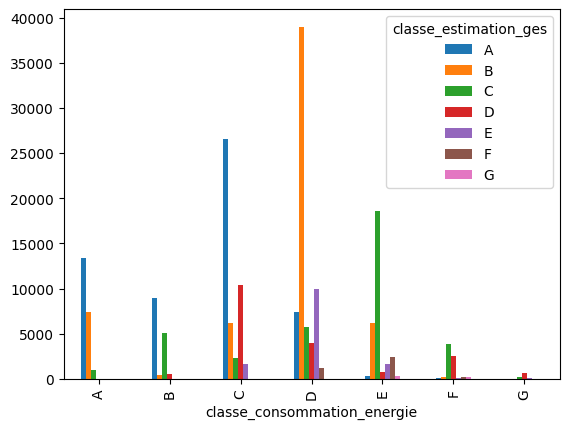

In [ ]:
# Visualization
pd.crosstab(df['classe_consommation_energie'], df['classe_estimation_ges']).plot(kind='bar')

**4.3 Key EDA Insights**


1. Right-skewed distribution of energy consumption

The variable **consommation_energie** exhibits a strongly right-skewed distribution. Most dwellings have moderate energy consumption levels, while a smaller number show very high values. This indicates the presence of highly energy-intensive buildings, although they are relatively rare.

2. Moderate positive correlation between energy consumption and GHG emissions  

A moderate positive correlation (approximately 0.35) is observed between **consommation_energie** and **estimation_ges**.  
This suggests that higher energy consumption is generally associated with higher greenhouse gas emissions, although the relationship is not strictly linear, likely due to differences in energy sources.

3. Significant influence of construction year  

There is a noticeable negative correlation between **annee_construction** and:
- energy consumption (approximately -0.57)  
- GHG emissions (approximately -0.43)

This indicates that more recent buildings tend to consume less energy and emit fewer greenhouse gases, reflecting improvements in construction standards and energy efficiency regulations over time.

4. Limited impact of habitable surface area  

The variable **surface_habitable** shows very weak correlation with:
- energy consumption (approximately -0.17)  
- GHG emissions (approximately 0.04)

This suggests that energy consumption depends more on the building's energy efficiency characteristics than on its size.

5. Strong relationship between energy classes and numerical values  

The boxplots reveal a clear pattern:
- As the energy class worsens from A to G, energy consumption increases significantly  
- A similar trend is observed for GHG emission classes  

This confirms the internal consistency of the DPE classification system.

6. Consistency between energy performance and GHG emissions  

The comparison between energy classes and GHG classes shows that:
- Highly efficient dwellings (A, B) are associated with low emissions  
- Less efficient dwellings (E, F, G) tend to have higher emissions  

This highlights a structured relationship between energy performance and environmental impact.

7. Overall Conclusion  

The analysis indicates that building age is a key determinant of energy performance, while energy consumption is moderately associated with greenhouse gas emissions. The DPE classification system appears consistent with the underlying numerical indicators.

**SECTION 5: HYPOTHESIS TESTING & STATISTICAL ANALYSIS**

**5.1 Hypothesis 1: Group Differences**

Do two groups differ in a numerical variable?

Group A (RAMATUELLE, SAINT TROPEZ, LE RAYOL CANADEL SUR MER):
  Mean: 198.944
  Median: 186.520
  Std Dev: 90.786

Group B (LE BOURGUET, BARGEME, TRIGANCE):
  Mean: 254.142
  Median: 221.270
  Std Dev: 104.335


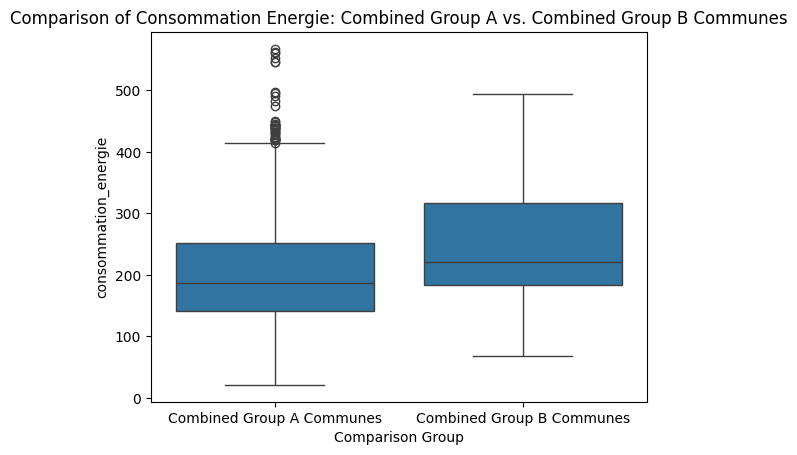


Normality Tests (Shapiro-Wilk):
  Group A: p-value = 0.0000 (Non-normal)
  Group B: p-value = 0.3786 (Normal)
  Levene Test: p-value = 0.2914 (Equal variances)

Independent Samples t-test:
  t-statistic: -3.3436
  p-value: 0.0008
  Significant at α=0.05? YES
  Cohen's d: -0.6062 (Medium effect)

📊 INTERPRETATION:
At the α = 0.05 significance level, we reject the null hypothesis.
There IS a statistically significant difference between groups.


In [ ]:
# Define the communes for Group A
group_A_communes = ['RAMATUELLE', 'SAINT TROPEZ', 'LE RAYOL CANADEL SUR MER']
group_A = df[df['commune'].isin(group_A_communes)]['consommation_energie']

# Define the communes for Group B (keeping the previous definition)
group_B_communes = ['LE BOURGUET', 'BARGEME', 'TRIGANCE']
group_B = df[df['commune'].isin(group_B_communes)]['consommation_energie']

# Descriptive statistics
print(f"Group A ({', '.join(group_A_communes)}):")
print(f"  Mean: {group_A.mean():.3f}")
print(f"  Median: {group_A.median():.3f}")
print(f"  Std Dev: {group_A.std():.3f}")
print(f"\nGroup B ({', '.join(group_B_communes)}):")
print(f"  Mean: {group_B.mean():.3f}")
print(f"  Median: {group_B.median():.3f}")
print(f"  Std Dev: {group_B.std():.3f}")

# Visualization
# Filter the DataFrame to include only the relevant communes for plotting
df_plot = df[df['commune'].isin(group_A_communes + group_B_communes)].copy()

# Create a new column for plotting to amalgamate communes into two groups
df_plot['Comparison Group'] = df_plot['commune'].apply(lambda x: 'Combined Group A Communes' if x in group_A_communes else 'Combined Group B Communes')

sns.boxplot(data=df_plot, x='Comparison Group', y='consommation_energie')
plt.title('Comparison of Consommation Energie: Combined Group A vs. Combined Group B Communes')
plt.show()

# Assumption Checks
from scipy.stats import shapiro, levene

# Normality test (Shapiro-Wilk)
stat_A, p_A = shapiro(group_A)
stat_B, p_B = shapiro(group_B)
print(f"\nNormality Tests (Shapiro-Wilk):")
print(f"  Group A: p-value = {p_A:.4f} {'(Normal)' if p_A > 0.05 else '(Non-normal)'}")
print(f"  Group B: p-value = {p_B:.4f} {'(Normal)' if p_B > 0.05 else '(Non-normal)'}")

# Equal variances test (Levene)
stat_lev, p_lev = levene(group_A, group_B)
print(f"  Levene Test: p-value = {p_lev:.4f} {'(Equal variances)' if p_lev > 0.05 else '(Unequal variances)'}")

# Hypothesis Test: Independent samples t-test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(group_A, group_B, equal_var=(p_lev > 0.05))

print(f"\nIndependent Samples t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at α=0.05? {'YES' if p_value < 0.05 else 'NO'}")

# Effect size (Cohen's d)
cohens_d = (group_A.mean() - group_B.mean()) / np.sqrt(((len(group_A)-1)*group_A.std()**2 + (len(group_B)-1)*group_B.std()**2) / (len(group_A) + len(group_B) - 2))
print(f"  Cohen's d: {cohens_d:.4f} ({'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'} effect)")

# Interpretation
print("\n📊 INTERPRETATION:")
print(f"At the α = 0.05 significance level, we {'reject' if p_value < 0.05 else 'fail to reject'} the null hypothesis.")
print(f"There {'IS' if p_value < 0.05 else 'IS NOT'} a statistically significant difference between groups.")

The analysis reveals a statistically significant difference in energy consumption between the two groups of communes. Group B shows a higher average energy consumption than Group A, as confirmed by both descriptive statistics and the t-test results (p-value = 0.0008), leading to the rejection of the null hypothesis. The effect size (Cohen’s d ≈ -0.61) indicates a moderate and meaningful difference.

However, this result should be interpreted in light of the socio-economic characteristics of the communes. Group A includes more affluent areas, while Group B corresponds to less affluent communes. This socio-economic contrast may influence energy consumption patterns in several ways.

For instance, wealthier households may invest more in energy-efficient buildings, insulation, or modern heating systems, leading to lower energy consumption despite potentially larger housing sizes. In contrast, less affluent areas may have older or less efficient buildings, contributing to higher energy consumption levels.

Therefore, the observed difference is likely not solely due to geographic location, but also reflects underlying socio-economic factors that affect building quality and energy efficiency. This highlights the importance of considering potential confounding variables when interpreting the results.

**5.2 Hypothesis 2: Categorical Association**

Are two categorical variables related?

In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df['classe_consommation_energie'], df['classe_estimation_ges'])
print("Contingency Table:")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Test:")
print(f"  χ² statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.20f}")  # Display p-value with more decimals
print(f"  Degrees of freedom: {dof}")
print(f"  Significant? {'YES' if p_value < 0.05 else 'NO'}")

# Cramér's V (effect size)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"  Cramér's V: {cramers_v:.4f}")

Contingency Table:
classe_estimation_ges            A      B      C      D     E     F    G
classe_consommation_energie                                             
A                            13363   7438   1014      7     0     0    1
B                             8939    471   5071    520     4     0    1
C                            26536   6161   2302  10356  1614     0    0
D                             7421  38999   5735   3933  9937  1201    0
E                              312   6166  18639    801  1602  2413  352
F                              100    166   3837   2551   123   181  185
G                                0     13    256    627    47    10    7

Chi-Square Test:
  χ² statistic: 153423.6315
  p-value: 0.00000000000000000000
  Degrees of freedom: 36
  Significant? YES
  Cramér's V: 0.3674


A p-value can never truly be zero; it only means it's extremely small. Even with 20 decimal places, the p-value still shows 0.00000000000000000000. This simply means that the calculated p-value is an incredibly tiny number, far smaller than what can be precisely represented even with that many decimal places. For all practical purposes, a p-value this small indicates an extremely strong statistical significance.

The results of the Chi-Square Test:

χ² statistic: 153423.6315
p-value: 0.00000000000000000000 (extremely small, highly significant)
Degrees of freedom: 36
Significant? YES
This overwhelmingly significant p-value tells us that there is a very strong statistical association between the classe_consommation_energie (energy consumption class) and the classe_estimation_ges (greenhouse gas emission class). In simpler terms, these two categorical variables are highly related.

Cramér's V: 0.3674
Cramér's V is an effect size measure for chi-square tests. A value of 0.3674 indicates a medium to strong association between the two variables. This suggests that while there is a significant relationship, it's not a perfect one-to-one correspondence, but it's substantial enough to be meaningful.

In summary, the energy consumption class and the greenhouse gas emission class are not independent; they are significantly and moderately-to-strongly associated with each other. This is expected, as energy consumption directly contributes to greenhouse gas emissions.

**5.3 Hypothesis 3: Relationship/Correlation**

Is there a linear relationship between two numerical variables?

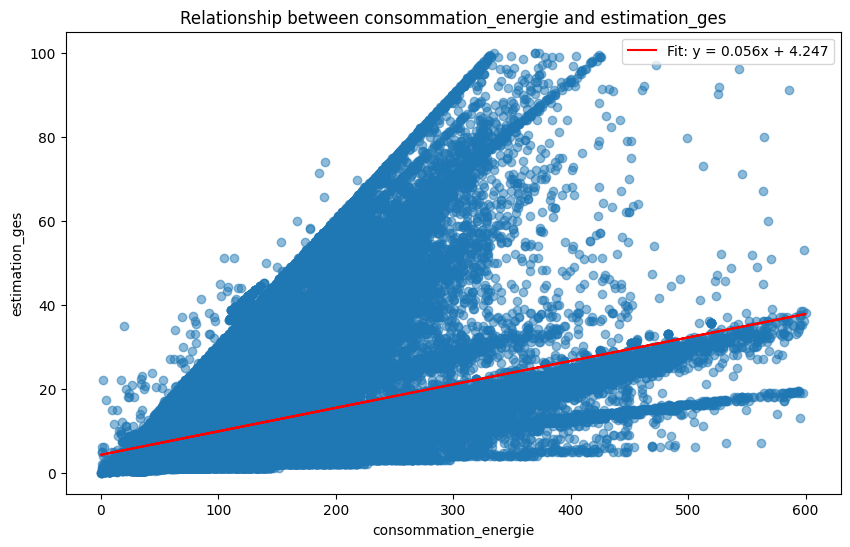


Linear Regression Results:
  Correlation (r): 0.3484
  R²: 0.1214
  Slope: 0.0559 (±0.0003)
  Intercept: 4.2472
  p-value: 0.00000000000000000000
  Significant? YES

📊 INTERPRETATION:
There IS a statistically significant linear relationship.
The model explains 12.1% of the variance in the outcome.


In [ ]:
from scipy.stats import linregress

# Choose two variables
x = df['consommation_energie']
y = df['estimation_ges']

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)

slope, intercept, r_value, p_value, std_err = linregress(x, y)
line = slope * x + intercept
plt.plot(x, line, 'r-', label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')

plt.xlabel('consommation_energie')
plt.ylabel('estimation_ges')
plt.title('Relationship between consommation_energie and estimation_ges')
plt.legend()
plt.show()

print(f"\nLinear Regression Results:")
print(f"  Correlation (r): {r_value:.4f}")
print(f"  R²: {r_value**2:.4f}")
print(f"  Slope: {slope:.4f} (±{std_err:.4f})")
print(f"  Intercept: {intercept:.4f}")
print(f"  p-value: {p_value:.20f}") # Display p-value with 20 decimal places
print(f"  Significant? {'YES' if p_value < 0.05 else 'NO'}")

print("\n📊 INTERPRETATION:")
print(f"There {'IS' if p_value < 0.05 else 'IS NOT'} a statistically significant linear relationship.")
print(f"The model explains {r_value**2 * 100:.1f}% of the variance in the outcome.")

Linear Regression Results:

Correlation (r): 0.3484 - This indicates a weak to moderate positive linear correlation between consommation_energie and estimation_ges.
R²: 0.1214 - This means that approximately 12.14% of the variance in estimation_ges can be explained by consommation_energie through this linear model.

At the α = 0.05 significance level, we reject the null hypothesis. This means there is a statistically significant linear relationship between consommation_energie and estimation_ges. The extremely small p-value reinforces this conclusion. The model explains 12.1% of the variance in the outcome, indicating that while the relationship is significant, there's a lot of variability in estimation_ges that is not accounted for by consommation_energie alone. The scatter plot also visually confirms this trend with a positive slope.